In [1]:
####### Input file ########################
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
data = pd.read_csv('Data_based_on_Speech_onset_plus_participants_demographics.csv')

In [2]:

##### selcting data points which are ncessary #########################

filtered_data = data.loc[:, ~data.columns.str.contains('trigger_reset_time_')]


# Mapping of old prefixes to new abbreviations
prefix_mapping = {
    "PointingDirectionX_2D": "ptx",
    "PointingDirectionZ_2D": "ptz",
    "HeadGazeDirectionX_2D": "hgx",
    "HeadGazeDirectionZ_2D": "hgz",
    "HeadposeX_smoothed": "hpx",
    "HeadposeZ_smoothed": "hpz",
    "GazeX_smoothed": "gzx",
    "GazeZ_smoothed": "gzz"
}

# Generate new column names based on the mapping
new_column_names = {}
for col in filtered_data.columns:
    for old_prefix, new_prefix in prefix_mapping.items():
        if col.startswith(old_prefix):
            # Extract the numeric suffix if present and construct the new column name
            suffix = col.split(old_prefix)[-1]
            new_column_names[col] = new_prefix + suffix

# Apply the renaming
renamed_data = filtered_data.rename(columns=new_column_names)

# Display the first few rows to verify the changes
renamed_data.head()

renamed_data.to_csv('filled_data.csv', index=False)

# Correcting the process to remove columns starting with "Lateral" from the originally renamed dataset
columns_to_remove_from_renamed = [col for col in renamed_data.columns if col.startswith("Lateral")]
renamed_data_after_lateral_removal = renamed_data.drop(columns=columns_to_remove_from_renamed)

columns_to_remove_from_renamed = [col for col in renamed_data_after_lateral_removal.columns if col.startswith("NoOfBuildings")]
renamed_data_after_lateral_removal = renamed_data_after_lateral_removal.drop(columns=columns_to_remove_from_renamed)

columns_to_remove_from_renamed = [col for col in renamed_data_after_lateral_removal.columns if col.startswith("POIBuilding_new_")]
renamed_data_after_lateral_removal = renamed_data_after_lateral_removal.drop(columns=columns_to_remove_from_renamed)

columns_to_remove_from_renamed = [col for col in renamed_data_after_lateral_removal.columns if col.startswith("PoI_GT_centerLatAngle")]
renamed_data_after_lateral_removal = renamed_data_after_lateral_removal.drop(columns=columns_to_remove_from_renamed)

columns_to_remove_from_renamed = [col for col in renamed_data_after_lateral_removal.columns if col.startswith("PoI_GT_adjustedMinLatAngle_")]
renamed_data_after_lateral_removal = renamed_data_after_lateral_removal.drop(columns=columns_to_remove_from_renamed)

columns_to_remove_from_renamed = [col for col in renamed_data_after_lateral_removal.columns if col.startswith("PoI_GT_adjustedMaxLatAngle_")]
renamed_data_after_lateral_removal = renamed_data_after_lateral_removal.drop(columns=columns_to_remove_from_renamed)


renamed_columns = {
    'PoI_GT_visibleMinLatAngle': 'GTV_min',
    'PoI_GT_visibleMaxLatAngle': 'GTV_max',
     'PoI_GT_minLatAngle': 'GTL_min',
      'PoI_GT_maxLatAngle': 'GTL_max'
}
# Generate new column names based on the mapping
new_column_names = {}
for col in renamed_data_after_lateral_removal.columns:
    for old_prefix, new_prefix in renamed_columns.items():
        if col.startswith(old_prefix):
            # Extract the numeric suffix if present and construct the new column name
            suffix = col.split(old_prefix)[-1]
            new_column_names[col] = new_prefix + suffix

# Apply the renaming
renamed_data_after_lateral_removal = renamed_data_after_lateral_removal.rename(columns=new_column_names)

# Display the shape of the data before and after to confirm the number of columns removed
renamed_data_after_lateral_removal.to_csv('filled_data.csv', index=False)


In [3]:
########## removing unnecessary columns and adding regularity column ##################

new_data = renamed_data_after_lateral_removal
# Identify all unique sequence numbers for GTV_min_ and GTV_max_ columns
min_columns = [col for col in new_data.columns if col.startswith("GTV_min_")]
max_columns = [col for col in new_data.columns if col.startswith("GTV_max_")]

# Verify that we have a matching set of min and max columns
assert len(min_columns) == len(max_columns), "Mismatch in number of GTV_min_ and GTV_max_ columns"

# Calculate the average for each pair and create a new column GTV_avg_#
for i in range(len(min_columns)):
    min_col = min_columns[i]
    max_col = max_columns[i]
    avg_col = f'GTV_avg_{i}'  # Assuming the sequence number matches the index in the list
    new_data[avg_col] = new_data[[min_col, max_col]].mean(axis=1)
for i in range(len(min_columns)):
    min_col = min_columns[i]
    max_col = max_columns[i]
    avg_col = f'GTL_avg_{i}'  # Assuming the sequence number matches the index in the list
    new_data[avg_col] = new_data[[min_col, max_col]].mean(axis=1)
value_mapping = {
    'Less than once per month': 4,
    'Several times per month': 3,
    'Several times per week': 2,
    'Almost never': 5,
    'Daily': 1
}

# Apply the mapping to the column
new_data['regularity'] = new_data['Driving_regularity'].replace(value_mapping)
    
new_data.to_csv('re_uesful.csv')

In [4]:
# Function to calculate tangent inverse in degrees with NaN values skipped
import math
# Initialize an empty DataFrame to hold all angle calculations
all_angles_df = pd.DataFrame()
df=new_data
all_angles_df['regularity'] = df['regularity']  
all_angles_df['participant'] = df['Participant'] 
# Calculate arctan(ptx_i/ptz_i) in degrees for the ptx/ptz columns
for i in range(20):
    ptx_col = f"ptx_{i}"
    ptz_col = f"ptz_{i}"
    all_angles_df[f"pta_{i}"] = (np.arctan(df[ptx_col] /df[ptz_col]))

# For hgx/hgz columns
for i in range(20):
    hgx_col = f"hgx_{i}"
    hgz_col = f"hgz_{i}"
    # Only proceed if both columns exist in the data
    if hgx_col in df.columns and hgz_col in df.columns:
        all_angles_df[f"hga_{i}"] = (np.arctan(df[hgx_col] / df[hgz_col]))

# For hpx/hpz columns
for i in range(20):
    hpx_col = f"hpx_{i}"
    hpz_col = f"hpz_{i}"
    # Only proceed if both columns exist in the data
    if hpx_col in df.columns and hpz_col in df.columns:
        all_angles_df[f"hpa_{i}"] = (np.arctan(df[hpx_col] / df[hpz_col]))

# For gzx/gzz columns
for i in range(20):
    gzx_col = f"gzx_{i}"
    gzz_col = f"gzz_{i}"
    # Only proceed if both columns exist in the data
    if gzx_col in df.columns and gzz_col in df.columns:
        all_angles_df[f"gza_{i}"] = (np.arctan(df[gzx_col] / df[gzz_col]))
        
for i in range(20):
    gzx_col = f"GTV_avg_{i}"
    # Only proceed if both columns exist in the data
    if gzx_col in df.columns and gzz_col in df.columns:
        all_angles_df[f"GTV_avg_{i}"] = (df[gzx_col])

for i in range(20):
    gzx_col = f"GTL_avg_{i}"
    # Only proceed if both columns exist in the data
    if gzx_col in df.columns and gzz_col in df.columns:
        all_angles_df[f"GTL_avg_{i}"] = (df[gzx_col])
        
for i in range(20):
    gzx_col = f"GTV_min_{i}"
    # Only proceed if both columns exist in the data
    if gzx_col in df.columns and gzz_col in df.columns:
        all_angles_df[f"GTV_min_{i}"] = (df[gzx_col])

for i in range(20):
    gzx_col = f"GTV_max_{i}"
    # Only proceed if both columns exist in the data
    if gzx_col in df.columns and gzz_col in df.columns:
        all_angles_df[f"GTV_max_{i}"] = (df[gzx_col])
        
for i in range(20):
    gzx_col = f"GTL_min_{i}"
    # Only proceed if both columns exist in the data
    if gzx_col in df.columns and gzz_col in df.columns:
        all_angles_df[f"GTL_min_{i}"] = (df[gzx_col])

for i in range(20):
    gzx_col = f"GTL_max_{i}"
    # Only proceed if both columns exist in the data
    if gzx_col in df.columns and gzz_col in df.columns:
        all_angles_df[f"GTL_max_{i}"] = (df[gzx_col])

 
        
# Save the combined DataFrame to CSV
all_angles_df.to_csv('angles_rad.csv', index=False)




c:\users\kiran\appdata\local\programs\python\python37\lib\site-packages\ipykernel_launcher.py:42: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
c:\users\kiran\appdata\local\programs\python\python37\lib\site-packages\ipykernel_launcher.py:48: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
c:\users\kiran\appdata\local\programs\python\python37\lib\site-packages\ipykernel_launcher.py:54: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Con

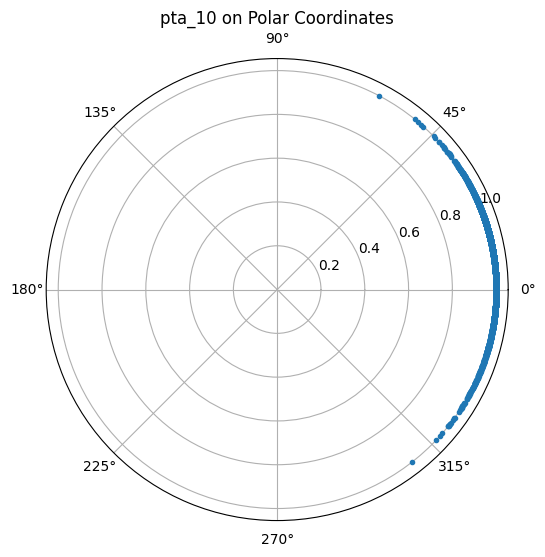

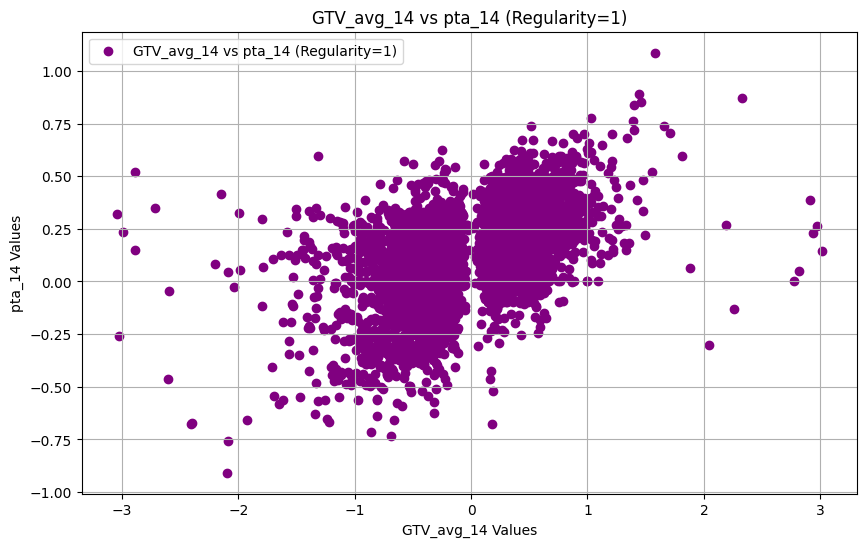

In [5]:
data = pd.read_csv('angles_rad.csv')
##### averaging data samples #####################
data=data.fillna(0)
pta_columns = [f'pta_{i}' for i in range(8, 11)]
gtv_columns = [f'GTV_avg_{i}' for i in range(8, 19)]
gtl_columns = [f'GTL_avg_{i}' for i in range(8, 19)]
hga_columns = [f'hga_{i}' for i in range(8, 11)]
gza_columns = [f'gza_{i}' for i in range(8, 11)]
hpa_columns = [f'hpa_{i}' for i in range(8, 11)]
gtv_min_columns = [f'GTV_min_{i}' for i in range(8, 19)]
gtv_max_columns = [f'GTV_max_{i}' for i in range(8, 19)]
gtl_min_columns = [f'GTL_min_{i}' for i in range(8, 19)]
gtl_max_columns = [f'GTL_max_{i}' for i in range(8, 19)]


data['gtv_min_average'] = data[gtv_min_columns].mean(axis=1)
data['gtv_max_average'] = data[gtv_max_columns].mean(axis=1)
data['gtl_min_average'] = data[gtl_min_columns].mean(axis=1)
data['gtl_max_average'] = data[gtl_max_columns].mean(axis=1)
data['pta_average'] = data[pta_columns].mean(axis=1)
data['gtv_average'] = data[gtv_columns].mean(axis=1)
data['gtl_average'] = data[gtl_columns].mean(axis=1)
data['hga_average'] = data[hga_columns].mean(axis=1)
data['gza_average'] = data[gza_columns].mean(axis=1)
data['hpa_average'] = data[hpa_columns].mean(axis=1)

data = data[data['gtv_min_average'] != 0]
data = data[data['gtv_max_average'] != 0]
data = data[data['gtl_min_average'] != 0]
data = data[data['gtl_max_average'] != 0]

data.to_csv('AVg.csv')
pta_14_regularity_1_values = data['hpa_average']

gtv_avg_14_regularity_1_values = data['gtv_average']

import matplotlib.pyplot as plt
import numpy as np

# Assuming 'all_angles_df' is your DataFrame and it contains 'pta_10'
# Convert 'pta_10' to a numpy array for plotting
angles = pta_14_regularity_1_values

# Create a new figure with a polar subplot
plt.figure(figsize=(8, 6))
ax = plt.subplot(111, polar=True)

# Plot 'pta_10' on the polar subplot
# Using 'np.ones_like(angles)' to have all points at a unit radius
ax.plot(angles, np.ones_like(angles), 'o', markersize=3)

# Set the title and adjust the grid
ax.set_title("pta_10 on Polar Coordinates")
ax.grid(True)
# Plotting GTV_avg_14 vs pta_14 for rows where regularity is 1
plt.figure(figsize=(10, 6))
plt.scatter(gtv_avg_14_regularity_1_values, pta_14_regularity_1_values, color='purple', label='GTV_avg_14 vs pta_14 (Regularity=1)')
plt.title('GTV_avg_14 vs pta_14 (Regularity=1)')
plt.xlabel('GTV_avg_14 Values')
plt.ylabel('pta_14 Values')
plt.legend()
plt.grid(True)
plt.show()



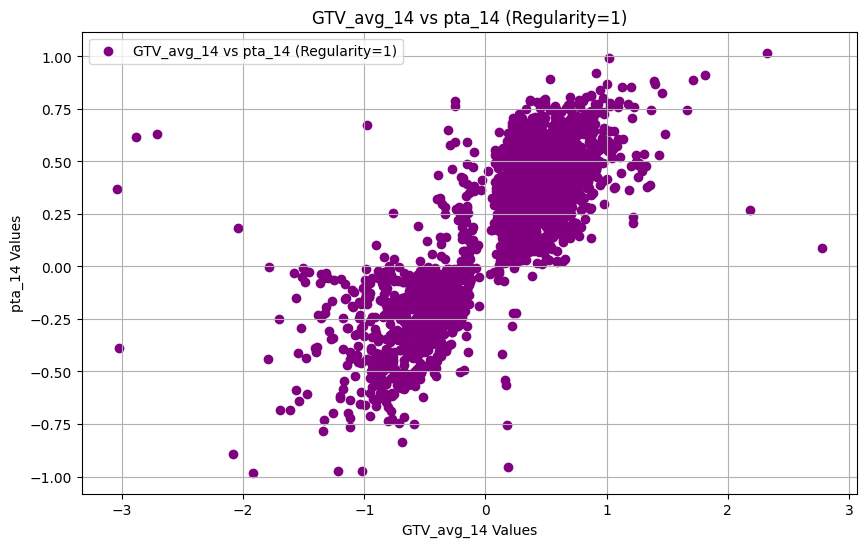

In [6]:
data = pd.read_csv('AVg.csv')
########### data filtering #################################
filtered_data = data[((data['pta_average'] >= 0) & (data['gza_average'] >= 0)) | ((data['pta_average'] < 0) & (data['gza_average'] < 0))]
data = filtered_data
filtered_data = data[((data['hga_average'] >= 0) & (data['gza_average'] >= 0)) | ((data['hga_average'] < 0) & (data['gza_average'] < 0))]
data = filtered_data
#filtered_data = data[((data['hpa_average'] >= 0) & (data['gza_average'] >= 0)) | ((data['hpa_average'] < 0) & (data['gza_average'] < 0))]

data.to_csv('AVg_cleaned2.csv')
pta_14_regularity_1_values = filtered_data['hga_average']

gtv_avg_14_regularity_1_values = filtered_data['gtv_average']

# Set the title and adjust the grid
ax.set_title("pta_10 on Polar Coordinates")
ax.grid(True)
# Plotting GTV_avg_14 vs pta_14 for rows where regularity is 1
plt.figure(figsize=(10, 6))
plt.scatter(gtv_avg_14_regularity_1_values, pta_14_regularity_1_values, color='purple', label='GTV_avg_14 vs pta_14 (Regularity=1)')
plt.title('GTV_avg_14 vs pta_14 (Regularity=1)')
plt.xlabel('GTV_avg_14 Values')
plt.ylabel('pta_14 Values')
plt.legend()
plt.grid(True)
plt.show()

In [7]:
#######alll the participants ###############

data = pd.read_csv('AVg_cleaned2.csv')
data['regularity_new'] = data['regularity'].replace({4: 6, 5: 6})
participants_by_new_regularity = data.groupby('regularity_new')['participant'].unique()

# Convert the result to a more readable format, such as a dictionary
participants_by_new_regularity_dict = participants_by_new_regularity.to_dict()

participants_by_new_regularity_dict

{1: array(['P25', 'P28', 'P38', 'P46', 'P47', 'P50', 'P54', 'P56', 'P74',
        'P75'], dtype=object),
 2: array(['P22', 'P26', 'P27', 'P29', 'P31', 'P32', 'P33', 'P40', 'P42',
        'P48', 'P49', 'P52', 'P61', 'P63', 'P64', 'P68', 'P72', 'P73',
        'P76'], dtype=object),
 3: array(['P21', 'P23', 'P30', 'P35', 'P36', 'P41', 'P43', 'P57', 'P65',
        'P66', 'P71', 'P77'], dtype=object),
 6: array(['P19', 'P24', 'P34', 'P37', 'P39', 'P44', 'P45', 'P51', 'P53',
        'P58', 'P59', 'P60', 'P67', 'P69', 'P70'], dtype=object)}

In [8]:
####### Train , val , and test split 

from sklearn.model_selection import train_test_split

# Initialize dictionaries to hold train and test splits for each regularity_new level
train_splits = {}
test_splits = {}

# For each regularity_new level, split the data into train and test sets on the participant level
for reg in data['regularity_new'].unique():
    # Select the subset of data for the current regularity_new level
    subset = data[data['regularity_new'] == reg]
    
    # Ensure that each participant is only in either train or test set (80:20 split)
    # First, get unique participants in the current subset
    unique_participants = subset['participant'].unique()
    
    # Split participants into train and test
    participants_train, participants_test = train_test_split(unique_participants, test_size=0.2, random_state=42)
    
    # Select rows corresponding to the train and test participants
    train = subset[subset['participant'].isin(participants_train)]
    test = subset[subset['participant'].isin(participants_test)]
    
    # Store the train and test subsets in the respective dictionaries
    train_splits[reg] = train
    test_splits[reg] = test

# To verify the split, let's check the number of rows in the original data vs the combined train and test splits
original_rows = data.shape[0]
train_rows = sum([df.shape[0] for df in train_splits.values()])
test_rows = sum([df.shape[0] for df in test_splits.values()])
combined_data_ordered = pd.concat([train_splits[reg] for reg in sorted(train_splits.keys())] + 
                                  [test_splits[reg] for reg in sorted(test_splits.keys())])
combined_data_ordered.to_csv('sec_part_data.csv', index=False)

original_rows, train_rows, test_rows


(2952, 2295, 657)

In [9]:
train_participants = {reg: df['participant'].unique() for reg, df in train_splits.items()}
test_participants = {reg: df['participant'].unique() for reg, df in test_splits.items()}

train_participants, test_participants

({6: array(['P24', 'P34', 'P37', 'P39', 'P44', 'P45', 'P51', 'P53', 'P59',
         'P67', 'P69', 'P70'], dtype=object),
  3: array(['P23', 'P30', 'P35', 'P36', 'P41', 'P43', 'P57', 'P65', 'P77'],
        dtype=object),
  2: array(['P27', 'P29', 'P31', 'P33', 'P40', 'P42', 'P48', 'P49', 'P61',
         'P63', 'P64', 'P68', 'P72', 'P73', 'P76'], dtype=object),
  1: array(['P25', 'P38', 'P46', 'P47', 'P50', 'P54', 'P56', 'P75'],
        dtype=object)},
 {6: array(['P19', 'P58', 'P60'], dtype=object),
  3: array(['P21', 'P66', 'P71'], dtype=object),
  2: array(['P22', 'P26', 'P32', 'P52'], dtype=object),
  1: array(['P28', 'P74'], dtype=object)})

In [10]:
###### this to generate data which has data where Mrde is lesss than 1 and test participants data .

import pandas as pd

# Load the initial datasets
data = pd.read_csv("predicted_data_sec_train.csv")
new_data = pd.read_csv("sec_part_data.csv")  # This contains all participants


updated_filtered_data = data[data['mre'] < 1]
filtered_data = data[data['mre'] < 1]

# Sort the filtered data by 'mre'
sorted_filtered_data = filtered_data.sort_values(by='mre')

# Select the first 75% of the sorted filtered data
selected_data = sorted_filtered_data.head(int(len(sorted_filtered_data) * 0.75))

updated_selected_data = selected_data

# Dictionary mapping group numbers to participant arrays
group_dict = {
    6: ['P19', 'P58', 'P60'],
    3: ['P21', 'P66', 'P71'],
    2: ['P22', 'P26', 'P32', 'P52'],
    1: ['P28', 'P74']
}

# Extract all test participants from the group dictionary
test_participants = [participant for group in group_dict.values() for participant in group]

# Function to process participant data, save it, and assign a group-based file name
def process_and_save_group_data(main_data, group_number):
    group_participants = group_dict[group_number]
    for participant_id in group_participants:
        # Filter the participant's specific data, identified as test participant
        specific_part_data = new_data[new_data['participant'] == participant_id]
        # Combine with the filtered dataset
        combined_data = pd.concat([main_data, specific_part_data], ignore_index=True)
        
        # Append remaining test set participants' data, excluding the current participant
        remaining_participants_data = new_data[new_data['participant'].isin(test_participants) & 
                                               ~new_data['participant'].isin([participant_id])]
        final_data = pd.concat([combined_data, remaining_participants_data], ignore_index=True)
        combined_length = len(combined_data)
        final_length = len(final_data)
        

        # Save to a CSV file named according to the group, participant ID, and lengths
        filename = f'Group{group_number}_{participant_id}_{combined_length}_{final_length}_data.csv'
        final_data.to_csv(filename, index=False)

# Process each group's participant data and save to separate files
for group_number in group_dict:
    process_and_save_group_data(updated_selected_data, group_number)


c:\users\kiran\appdata\local\programs\python\python37\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


1895
399
(1895, 3)
(1895, 1)
(399, 3)
(399, 1)


c:\users\kiran\appdata\local\programs\python\python37\lib\site-packages\ipykernel_launcher.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
c:\users\kiran\appdata\local\programs\python\python37\lib\site-packages\ipykernel_launcher.py:90: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).


MSE:  0.1762254685163498
RMSE:  0.4197921730051071


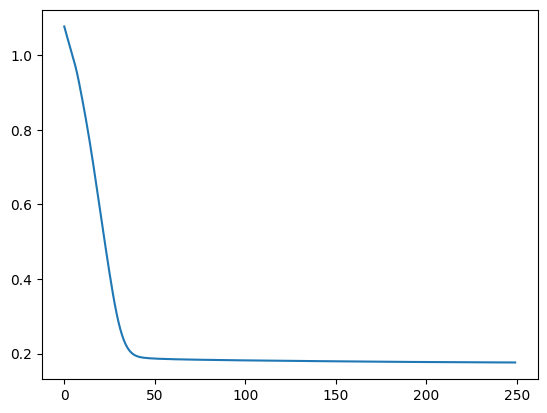

27.797972
23.223982
0.6717325227963525
1.1444514417672578


In [11]:
###### from here on it is only result comparision using ANNs ######### not related to ddpg . 



import copy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import tqdm
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
# Load the dataset from the uploaded file
df = pd.read_csv("shuffled_sec_part_data.csv")

df['gtl_average'] = np.degrees(df['gtl_average'])
df['pta_average'] = np.degrees(df['pta_average'])
df['gza_average'] = np.degrees(df['gza_average'])
df['gtl_min_average'] = np.degrees(df['gtl_min_average'])
df['gtl_max_average'] = np.degrees(df['gtl_max_average'])
df['hga_average'] = np.degrees( df['hga_average'])


# Further split the training and validation data
train_data = df[:1895]

val_data = df[1895: 2294]

test_data = df[2294 : ]

# Extract predictors and target
TargetVariable = ['gtl_average']
Predictors = ['pta_average', 'gza_average', 'hga_average']

X_train = (train_data[Predictors].values)
y_train = (train_data[TargetVariable].values)
    
X_test = (val_data[Predictors].values)
y_test = (val_data[TargetVariable].values)

x_t = (test_data[Predictors].values)
y_t = (test_data[TargetVariable].values)



from sklearn.preprocessing import StandardScaler


### Sandardization of data ###
from sklearn.preprocessing import StandardScaler
PredictorScaler=StandardScaler()
TargetVarScaler=StandardScaler()
 
# Storing the fit object for later reference
PredictorScalerFit=PredictorScaler.fit(X_train)
TargetVarScalerFit=TargetVarScaler.fit(y_train)
 
# Generating the standardized values of X and y
X_train=PredictorScalerFit.transform(X_train)
y_train=TargetVarScalerFit.transform(y_train)
X_test=PredictorScalerFit.transform(X_test)
y_test=TargetVarScalerFit.transform(y_test)

x_t=PredictorScalerFit.transform(x_t)
y_t=TargetVarScalerFit.transform(y_t)
x_t = torch.tensor(x_t, dtype=torch.float32)
y_t = torch.tensor(y_t, dtype=torch.float32)

print(len(X_train))
print(len(X_test))
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)




# Read data
#data = fetch_california_housing()
#X, y = data.data, data.target

# train-test split for model evaluation
#X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=True)

# Convert to 2D PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)
x_t = torch.tensor(x_t, dtype=torch.float32)
y_t = torch.tensor(y_t, dtype=torch.float32)

# Define the model
model = nn.Sequential(
    nn.Linear(3, 12),
    nn.ReLU(),
    nn.Linear(12, 24),
    nn.ReLU(),
    nn.Linear(24, 12),
    nn.ReLU(),
    nn.Linear(12, 1)
)

# loss function and optimizer
loss_fn = nn.MSELoss()  # mean square error
optimizer = optim.Adam(model.parameters(), lr=0.0001)

n_epochs = 250   # number of epochs to run
batch_size = 100  # size of each batch
batch_start = torch.arange(0, len(X_train), batch_size)

# Hold the best model
best_mse = np.inf   # init to infinity
best_weights = None
history = []

for epoch in range(n_epochs):
    model.train()
    with tqdm.tqdm(batch_start, unit="batch", mininterval=0, disable=True) as bar:
        bar.set_description(f"Epoch {epoch}")
        for start in bar:
            # take a batch
            X_batch = X_train[start:start+batch_size]
            y_batch = y_train[start:start+batch_size]
            # forward pass
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            # backward pass
            optimizer.zero_grad()
            loss.backward()
            # update weights
            optimizer.step()
            # print progress
            bar.set_postfix(mse=float(loss))
    # evaluate accuracy at end of each epoch
    model.eval()
    y_pred = model(X_test)
    mse = loss_fn(y_pred, y_test)
    mse = float(mse)
    history.append(mse)
    if mse < best_mse:
        best_mse = mse
        best_weights = copy.deepcopy(model.state_dict())

# restore model and return best accuracy
model.load_state_dict(best_weights)
print("MSE: " , best_mse)
print("RMSE: " , np.sqrt(best_mse))
plt.plot(history)
plt.show()

a = TargetVarScalerFit.inverse_transform(model(X_test).detach().numpy())
from sklearn.metrics import mean_squared_error
rms = mean_squared_error(y_test.numpy(), a, squared=False)
print(rms)
a = TargetVarScalerFit.inverse_transform(model(x_t).detach().numpy())
rms = mean_squared_error(y_t.numpy(), a, squared=False)
print(rms)
a_flat = a[:, 0]
hbw = abs(test_data['gtl_min_average'] - test_data['gtl_max_average'])/2

acc= abs( test_data['gtl_average'] -  a[:, 0] ) / hbw
print(( acc < 1).sum() / len(acc)  )

print( acc .sum() / len(acc)  )
pointing_model =model
scaled_predictions = TargetVarScalerFit.inverse_transform(model(X_train).detach().numpy())





(1895, 3)
(1895, 1)
(399, 3)
(399, 1)


c:\users\kiran\appdata\local\programs\python\python37\lib\site-packages\ipykernel_launcher.py:86: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
c:\users\kiran\appdata\local\programs\python\python37\lib\site-packages\ipykernel_launcher.py:87: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).


MSE:  0.18249966204166412
RMSE:  0.4271997917153801


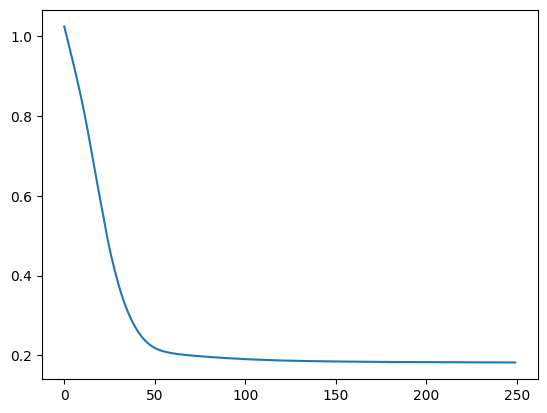

27.78385
23.27394
0.4072948328267477
3.8120480528260297


In [12]:
import copy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import tqdm
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
# Load the dataset from the uploaded file
df = pd.read_csv("shuffled_sec_part_data.csv")

df['gtv_average'] = np.degrees(df['gtv_average'])
df['pta_average'] = np.degrees(df['pta_average'])
df['gza_average'] = np.degrees(df['gza_average'])
df['gtv_min_average'] = np.degrees(df['gtv_min_average'])
df['gtv_max_average'] = np.degrees(df['gtv_max_average'])
df['hga_average'] = np.degrees( df['hga_average'])

# Further split the training and validation data
train_data = df[:1895]

val_data = df[1895: 2294]

test_data = df[2294 : ]


# Extract predictors and target
TargetVariable = ['gtv_average']
Predictors = ['pta_average', 'gza_average', 'hga_average']

X_train = (train_data[Predictors].values)
y_train = (train_data[TargetVariable].values)
    
X_test = (val_data[Predictors].values)
y_test = (val_data[TargetVariable].values)

x_t = (test_data[Predictors].values)
y_t = (test_data[TargetVariable].values)



from sklearn.preprocessing import StandardScaler


### Sandardization of data ###
from sklearn.preprocessing import StandardScaler
PredictorScaler=StandardScaler()
TargetVarScaler=StandardScaler()
 
# Storing the fit object for later reference
PredictorScalerFit=PredictorScaler.fit(X_train)
TargetVarScalerFit=TargetVarScaler.fit(y_train)
 
# Generating the standardized values of X and y
X_train=PredictorScalerFit.transform(X_train)
y_train=TargetVarScalerFit.transform(y_train)
X_test=PredictorScalerFit.transform(X_test)
y_test=TargetVarScalerFit.transform(y_test)

x_t=PredictorScalerFit.transform(x_t)
y_t=TargetVarScalerFit.transform(y_t)
x_t = torch.tensor(x_t, dtype=torch.float32)
y_t = torch.tensor(y_t, dtype=torch.float32)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)




# Read data
#data = fetch_california_housing()
#X, y = data.data, data.target

# train-test split for model evaluation
#X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=True)

# Convert to 2D PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)
x_t = torch.tensor(x_t, dtype=torch.float32)
y_t = torch.tensor(y_t, dtype=torch.float32)

# Define the model
model = nn.Sequential(
    nn.Linear(3, 12),
    nn.ReLU(),
    nn.Linear(12, 24),
    nn.ReLU(),
    nn.Linear(24, 12),
    nn.ReLU(),
    nn.Linear(12, 1)
)

# loss function and optimizer
loss_fn = nn.MSELoss()  # mean square error
optimizer = optim.Adam(model.parameters(), lr=0.0001)

n_epochs = 250   # number of epochs to run
batch_size = 100  # size of each batch
batch_start = torch.arange(0, len(X_train), batch_size)

# Hold the best model
best_mse = np.inf   # init to infinity
best_weights = None
history = []

for epoch in range(n_epochs):
    model.train()
    with tqdm.tqdm(batch_start, unit="batch", mininterval=0, disable=True) as bar:
        bar.set_description(f"Epoch {epoch}")
        for start in bar:
            # take a batch
            X_batch = X_train[start:start+batch_size]
            y_batch = y_train[start:start+batch_size]
            # forward pass
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            # backward pass
            optimizer.zero_grad()
            loss.backward()
            # update weights
            optimizer.step()
            # print progress
            bar.set_postfix(mse=float(loss))
    # evaluate accuracy at end of each epoch
    model.eval()
    y_pred = model(X_test)
    mse = loss_fn(y_pred, y_test)
    mse = float(mse)
    history.append(mse)
    if mse < best_mse:
        best_mse = mse
        best_weights = copy.deepcopy(model.state_dict())

# restore model and return best accuracy
model.load_state_dict(best_weights)
print("MSE: " , best_mse)
print("RMSE: " , np.sqrt(best_mse))
plt.plot(history)
plt.show()

a = TargetVarScalerFit.inverse_transform(model(X_test).detach().numpy())
from sklearn.metrics import mean_squared_error
rms = mean_squared_error(y_test.numpy(), a, squared=False)
print(rms)
a = TargetVarScalerFit.inverse_transform(model(x_t).detach().numpy())
rms = mean_squared_error(y_t.numpy(), a, squared=False)
print(rms)
a_flat = a[:, 0]
hbw = abs(test_data['gtv_min_average'] - test_data['gtv_max_average'])/2

acc= abs( test_data['gtv_average'] -  a[:, 0] ) / hbw
print(( acc < 1).sum() / len(acc)  )

print( acc .sum() / len(acc)  )
pointing_model =model
scaled_predictions = TargetVarScalerFit.inverse_transform(model(X_train).detach().numpy())
# Assuming you want to create a new column 'pointing' in a DataFrame
#predictions["pointing"] = scaled_predictions[:, 0]  # Assuming the first column is for 'pointing'
# Calculate MAE for the test set



407
46
(407, 1)
(407, 1)
(46, 1)
(46, 1)


c:\users\kiran\appdata\local\programs\python\python37\lib\site-packages\ipykernel_launcher.py:98: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
c:\users\kiran\appdata\local\programs\python\python37\lib\site-packages\ipykernel_launcher.py:99: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).


MSE:  0.22369393706321716
RMSE:  0.47296293413249324


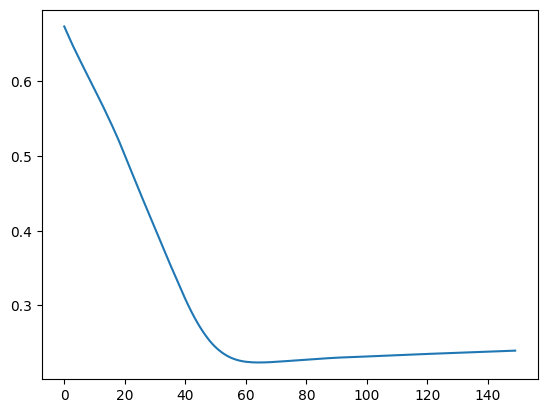

34.95747
29.02995
0.5210084033613446
1.9625201839134283


In [33]:
import copy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import tqdm
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
# Load the dataset from the uploaded file
df = pd.read_csv("shuffled_sec_part_data.csv")

df['gtl_average'] = np.degrees(df['gtl_average'])
df['pta_average'] = np.degrees(df['pta_average'])
df['gza_average'] = np.degrees(df['gza_average'])
df['gtl_min_average'] = np.degrees(df['gtl_min_average'])
df['gtl_max_average'] = np.degrees(df['gtl_max_average'])
df['hga_average'] = np.degrees( df['hga_average'])
df['difference'] = df['pta_average']  - df['gza_average'] 


# Split the data into training and testing sets
train_val_data = df[:2294]
test_data = df[2294:]

# Shuffle the training and validation data
#train_val_data = train_val_data.sample(frac=1, random_state=42).reset_index(drop=True)

train_val_data = train_val_data[train_val_data['difference'] < 0]
test_data = test_data[test_data['difference'] < 0]

from sklearn.model_selection import train_test_split

# Assuming train_val_data is a pandas DataFrame
train_data, val_data = train_test_split(train_val_data, test_size=0.1, random_state=42)

# Extract predictors and target
TargetVariable = ['gtl_average']
Predictors = ['pta_average']

X_train = (train_data[Predictors].values)
y_train = (train_data[TargetVariable].values)
    
X_test = (val_data[Predictors].values)
y_test = (val_data[TargetVariable].values)

x_t = (test_data[Predictors].values)
y_t = (test_data[TargetVariable].values)



from sklearn.preprocessing import StandardScaler


### Sandardization of data ###
from sklearn.preprocessing import StandardScaler
PredictorScaler=StandardScaler()
TargetVarScaler=StandardScaler()
 
# Storing the fit object for later reference
PredictorScalerFit=PredictorScaler.fit(X_train)
TargetVarScalerFit=TargetVarScaler.fit(y_train)
 
# Generating the standardized values of X and y
X_train=PredictorScalerFit.transform(X_train)
y_train=TargetVarScalerFit.transform(y_train)
X_test=PredictorScalerFit.transform(X_test)
y_test=TargetVarScalerFit.transform(y_test)

x_t=PredictorScalerFit.transform(x_t)
y_t=TargetVarScalerFit.transform(y_t)
x_t = torch.tensor(x_t, dtype=torch.float32)
y_t = torch.tensor(y_t, dtype=torch.float32)

print(len(X_train))
print(len(X_test))
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)




# Read data
#data = fetch_california_housing()
#X, y = data.data, data.target

# train-test split for model evaluation
#X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=True)

# Convert to 2D PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)
x_t = torch.tensor(x_t, dtype=torch.float32)
y_t = torch.tensor(y_t, dtype=torch.float32)

# Define the model
model = nn.Sequential(
    nn.Linear(1, 48),
    nn.ReLU(),
    nn.Linear(48, 24),
    nn.ReLU(),
    nn.Linear(24, 12),
    nn.ReLU(),
    nn.Linear(12, 1)
)

# loss function and optimizer
loss_fn = nn.MSELoss()  # mean square error
optimizer = optim.Adam(model.parameters(), lr=0.0002)

n_epochs = 150   # number of epochs to run
batch_size = 128 # size of each batch
batch_start = torch.arange(0, len(X_train), batch_size)

# Hold the best model
best_mse = np.inf   # init to infinity
best_weights = None
history = []

for epoch in range(n_epochs):
    model.train()
    with tqdm.tqdm(batch_start, unit="batch", mininterval=0, disable=True) as bar:
        bar.set_description(f"Epoch {epoch}")
        for start in bar:
            # take a batch
            X_batch = X_train[start:start+batch_size]
            y_batch = y_train[start:start+batch_size]
            # forward pass
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            # backward pass
            optimizer.zero_grad()
            loss.backward()
            # update weights
            optimizer.step()
            # print progress
            bar.set_postfix(mse=float(loss))
    # evaluate accuracy at end of each epoch
    model.eval()
    y_pred = model(X_test)
    mse = loss_fn(y_pred, y_test)
    mse = float(mse)
    history.append(mse)
    if mse < best_mse:
        best_mse = mse
        best_weights = copy.deepcopy(model.state_dict())

# restore model and return best accuracy
model.load_state_dict(best_weights)
print("MSE: " , best_mse)
print("RMSE: " , np.sqrt(best_mse))
plt.plot(history)
plt.show()

a = TargetVarScalerFit.inverse_transform(model(X_test).detach().numpy())
from sklearn.metrics import mean_squared_error
rms = mean_squared_error(y_test.numpy(), a, squared=False)
print(rms)
a = TargetVarScalerFit.inverse_transform(model(x_t).detach().numpy())
rms = mean_squared_error(y_t.numpy(), a, squared=False)
print(rms)
a_flat = a[:, 0]
hbw = abs(test_data['gtl_min_average'] - test_data['gtl_max_average'])/2

acc= abs( test_data['gtl_average'] -  a[:, 0] ) / hbw
print(( acc < 1).sum() / len(acc)  )

print( acc .sum() / len(acc)  )
pointing_model =model
scaled_predictions = TargetVarScalerFit.inverse_transform(model(X_train).detach().numpy())





1656
185
(1656, 2)
(1656, 1)
(185, 2)
(185, 1)


c:\users\kiran\appdata\local\programs\python\python37\lib\site-packages\ipykernel_launcher.py:98: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
c:\users\kiran\appdata\local\programs\python\python37\lib\site-packages\ipykernel_launcher.py:99: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).


MSE:  0.23258192837238312
RMSE:  0.4822674863313752


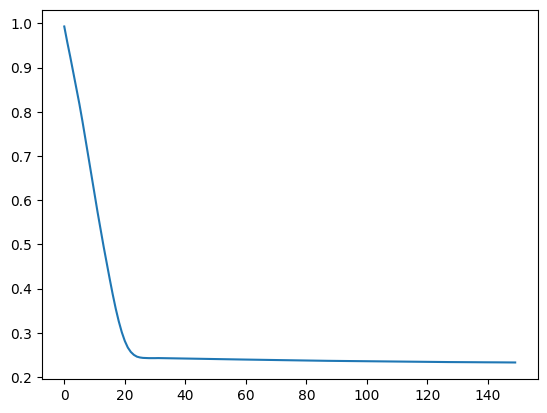

26.984806
22.846745
0.6233766233766234
1.0982929302446238


In [34]:
import copy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import tqdm
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
# Load the dataset from the uploaded file
df = pd.read_csv("shuffled_sec_part_data.csv")

df['gtl_average'] = np.degrees(df['gtl_average'])
df['pta_average'] = np.degrees(df['pta_average'])
df['gza_average'] = np.degrees(df['gza_average'])
df['gtl_min_average'] = np.degrees(df['gtl_min_average'])
df['gtl_max_average'] = np.degrees(df['gtl_max_average'])
df['hga_average'] = np.degrees( df['hga_average'])
df['difference'] = df['pta_average']  - df['gza_average'] 


# Split the data into training and testing sets
train_val_data = df[:2294]
test_data = df[2294:]

# Shuffle the training and validation data
#train_val_data = train_val_data.sample(frac=1, random_state=42).reset_index(drop=True)

train_val_data = train_val_data[train_val_data['difference'] > 0]
test_data = test_data[test_data['difference'] > 0]

from sklearn.model_selection import train_test_split

# Assuming train_val_data is a pandas DataFrame
train_data, val_data = train_test_split(train_val_data, test_size=0.1, random_state=42)

# Extract predictors and target
TargetVariable = ['gtl_average']
Predictors = ['pta_average', 'gza_average']

X_train = (train_data[Predictors].values)
y_train = (train_data[TargetVariable].values)
    
X_test = (val_data[Predictors].values)
y_test = (val_data[TargetVariable].values)

x_t = (test_data[Predictors].values)
y_t = (test_data[TargetVariable].values)



from sklearn.preprocessing import StandardScaler


### Sandardization of data ###
from sklearn.preprocessing import StandardScaler
PredictorScaler=StandardScaler()
TargetVarScaler=StandardScaler()
 
# Storing the fit object for later reference
PredictorScalerFit=PredictorScaler.fit(X_train)
TargetVarScalerFit=TargetVarScaler.fit(y_train)
 
# Generating the standardized values of X and y
X_train=PredictorScalerFit.transform(X_train)
y_train=TargetVarScalerFit.transform(y_train)
X_test=PredictorScalerFit.transform(X_test)
y_test=TargetVarScalerFit.transform(y_test)

x_t=PredictorScalerFit.transform(x_t)
y_t=TargetVarScalerFit.transform(y_t)
x_t = torch.tensor(x_t, dtype=torch.float32)
y_t = torch.tensor(y_t, dtype=torch.float32)

print(len(X_train))
print(len(X_test))
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)




# Read data
#data = fetch_california_housing()
#X, y = data.data, data.target

# train-test split for model evaluation
#X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=True)

# Convert to 2D PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)
x_t = torch.tensor(x_t, dtype=torch.float32)
y_t = torch.tensor(y_t, dtype=torch.float32)

# Define the model
model = nn.Sequential(
    nn.Linear(2, 48),
    nn.ReLU(),
    nn.Linear(48, 24),
    nn.ReLU(),
    nn.Linear(24, 12),
    nn.ReLU(),
    nn.Linear(12, 1)
)

# loss function and optimizer
loss_fn = nn.MSELoss()  # mean square error
optimizer = optim.Adam(model.parameters(), lr=0.0002)

n_epochs = 150   # number of epochs to run
batch_size = 128 # size of each batch
batch_start = torch.arange(0, len(X_train), batch_size)

# Hold the best model
best_mse = np.inf   # init to infinity
best_weights = None
history = []

for epoch in range(n_epochs):
    model.train()
    with tqdm.tqdm(batch_start, unit="batch", mininterval=0, disable=True) as bar:
        bar.set_description(f"Epoch {epoch}")
        for start in bar:
            # take a batch
            X_batch = X_train[start:start+batch_size]
            y_batch = y_train[start:start+batch_size]
            # forward pass
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            # backward pass
            optimizer.zero_grad()
            loss.backward()
            # update weights
            optimizer.step()
            # print progress
            bar.set_postfix(mse=float(loss))
    # evaluate accuracy at end of each epoch
    model.eval()
    y_pred = model(X_test)
    mse = loss_fn(y_pred, y_test)
    mse = float(mse)
    history.append(mse)
    if mse < best_mse:
        best_mse = mse
        best_weights = copy.deepcopy(model.state_dict())

# restore model and return best accuracy
model.load_state_dict(best_weights)
print("MSE: " , best_mse)
print("RMSE: " , np.sqrt(best_mse))
plt.plot(history)
plt.show()

a = TargetVarScalerFit.inverse_transform(model(X_test).detach().numpy())
from sklearn.metrics import mean_squared_error
rms = mean_squared_error(y_test.numpy(), a, squared=False)
print(rms)
a = TargetVarScalerFit.inverse_transform(model(x_t).detach().numpy())
rms = mean_squared_error(y_t.numpy(), a, squared=False)
print(rms)
a_flat = a[:, 0]
hbw = abs(test_data['gtl_min_average'] - test_data['gtl_max_average'])/2

acc= abs( test_data['gtl_average'] -  a[:, 0] ) / hbw
print(( acc < 1).sum() / len(acc)  )

print( acc .sum() / len(acc)  )
pointing_model =model
scaled_predictions = TargetVarScalerFit.inverse_transform(model(X_train).detach().numpy())





(1656, 2)
(1656, 1)
(185, 2)
(185, 1)


c:\users\kiran\appdata\local\programs\python\python37\lib\site-packages\ipykernel_launcher.py:95: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
c:\users\kiran\appdata\local\programs\python\python37\lib\site-packages\ipykernel_launcher.py:96: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).


MSE:  0.23453038930892944
RMSE:  0.4842833770726902


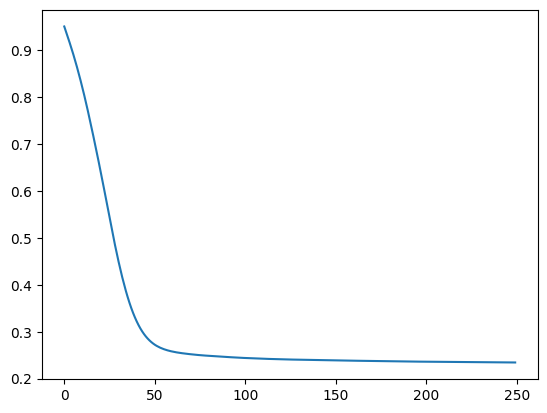

26.83414
22.728806
0.3877551020408163
3.1030493704302264


In [36]:
import copy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import tqdm
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
# Load the dataset from the uploaded file
df = pd.read_csv("shuffled_sec_part_data.csv")

df['gtv_average'] = np.degrees(df['gtv_average'])
df['pta_average'] = np.degrees(df['pta_average'])
df['gza_average'] = np.degrees(df['gza_average'])
df['gtv_min_average'] = np.degrees(df['gtv_min_average'])
df['gtv_max_average'] = np.degrees(df['gtv_max_average'])
df['hga_average'] = np.degrees( df['hga_average'])
df['difference'] = df['pta_average']  - df['gza_average']

# Split the data into training and testing sets
train_val_data = df[:2294]
test_data = df[2294:]

# Shuffle the training and validation data
#train_val_data = train_val_data.sample(frac=1, random_state=42).reset_index(drop=True)

train_val_data = train_val_data[train_val_data['difference'] > 0]
test_data = test_data[test_data['difference'] > 0]

from sklearn.model_selection import train_test_split

# Assuming train_val_data is a pandas DataFrame
train_data, val_data = train_test_split(train_val_data, test_size=0.1, random_state=42)


# Extract predictors and target
TargetVariable = ['gtv_average']
Predictors = ['pta_average', 'gza_average']

X_train = (train_data[Predictors].values)
y_train = (train_data[TargetVariable].values)
    
X_test = (val_data[Predictors].values)
y_test = (val_data[TargetVariable].values)

x_t = (test_data[Predictors].values)
y_t = (test_data[TargetVariable].values)



from sklearn.preprocessing import StandardScaler


### Sandardization of data ###
from sklearn.preprocessing import StandardScaler
PredictorScaler=StandardScaler()
TargetVarScaler=StandardScaler()
 
# Storing the fit object for later reference
PredictorScalerFit=PredictorScaler.fit(X_train)
TargetVarScalerFit=TargetVarScaler.fit(y_train)
 
# Generating the standardized values of X and y
X_train=PredictorScalerFit.transform(X_train)
y_train=TargetVarScalerFit.transform(y_train)
X_test=PredictorScalerFit.transform(X_test)
y_test=TargetVarScalerFit.transform(y_test)

x_t=PredictorScalerFit.transform(x_t)
y_t=TargetVarScalerFit.transform(y_t)
x_t = torch.tensor(x_t, dtype=torch.float32)
y_t = torch.tensor(y_t, dtype=torch.float32)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)




# Read data
#data = fetch_california_housing()
#X, y = data.data, data.target

# train-test split for model evaluation
#X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=True)

# Convert to 2D PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)
x_t = torch.tensor(x_t, dtype=torch.float32)
y_t = torch.tensor(y_t, dtype=torch.float32)

# Define the model
model = nn.Sequential(
    nn.Linear(2, 12),
    nn.ReLU(),
    nn.Linear(12, 24),
    nn.ReLU(),
    nn.Linear(24, 12),
    nn.ReLU(),
    nn.Linear(12, 1)
)

# loss function and optimizer
loss_fn = nn.MSELoss()  # mean square error
optimizer = optim.Adam(model.parameters(), lr=0.0001)

n_epochs = 250   # number of epochs to run
batch_size = 100  # size of each batch
batch_start = torch.arange(0, len(X_train), batch_size)

# Hold the best model
best_mse = np.inf   # init to infinity
best_weights = None
history = []

for epoch in range(n_epochs):
    model.train()
    with tqdm.tqdm(batch_start, unit="batch", mininterval=0, disable=True) as bar:
        bar.set_description(f"Epoch {epoch}")
        for start in bar:
            # take a batch
            X_batch = X_train[start:start+batch_size]
            y_batch = y_train[start:start+batch_size]
            # forward pass
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            # backward pass
            optimizer.zero_grad()
            loss.backward()
            # update weights
            optimizer.step()
            # print progress
            bar.set_postfix(mse=float(loss))
    # evaluate accuracy at end of each epoch
    model.eval()
    y_pred = model(X_test)
    mse = loss_fn(y_pred, y_test)
    mse = float(mse)
    history.append(mse)
    if mse < best_mse:
        best_mse = mse
        best_weights = copy.deepcopy(model.state_dict())

# restore model and return best accuracy
model.load_state_dict(best_weights)
print("MSE: " , best_mse)
print("RMSE: " , np.sqrt(best_mse))
plt.plot(history)
plt.show()

a = TargetVarScalerFit.inverse_transform(model(X_test).detach().numpy())
from sklearn.metrics import mean_squared_error
rms = mean_squared_error(y_test.numpy(), a, squared=False)
print(rms)
a = TargetVarScalerFit.inverse_transform(model(x_t).detach().numpy())
rms = mean_squared_error(y_t.numpy(), a, squared=False)
print(rms)
a_flat = a[:, 0]
hbw = abs(test_data['gtv_min_average'] - test_data['gtv_max_average'])/2

acc= abs( test_data['gtv_average'] -  a[:, 0] ) / hbw
print(( acc < 1).sum() / len(acc)  )

print( acc .sum() / len(acc)  )
pointing_model =model
scaled_predictions = TargetVarScalerFit.inverse_transform(model(X_train).detach().numpy())
# Assuming you want to create a new column 'pointing' in a DataFrame
#predictions["pointing"] = scaled_predictions[:, 0]  # Assuming the first column is for 'pointing'
# Calculate MAE for the test set



(407, 1)
(407, 1)
(46, 1)
(46, 1)


c:\users\kiran\appdata\local\programs\python\python37\lib\site-packages\ipykernel_launcher.py:95: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
c:\users\kiran\appdata\local\programs\python\python37\lib\site-packages\ipykernel_launcher.py:96: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).


MSE:  0.20906862616539001
RMSE:  0.4572402280698736


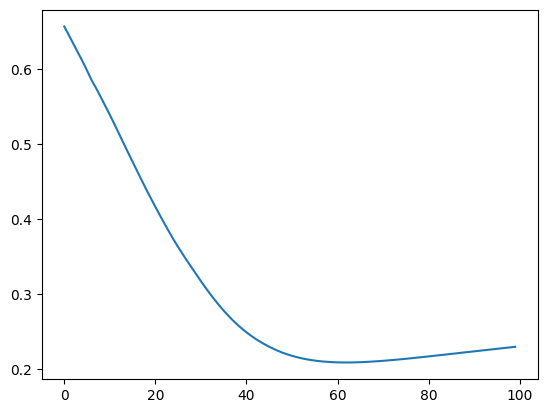

34.53191
27.04858
0.35294117647058826
7.259193096423185


In [73]:
import copy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import tqdm
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
# Load the dataset from the uploaded file
df = pd.read_csv("shuffled_sec_part_data.csv")

df['gtv_average'] = np.degrees(df['gtv_average'])
df['pta_average'] = np.degrees(df['pta_average'])
df['gza_average'] = np.degrees(df['gza_average'])
df['gtv_min_average'] = np.degrees(df['gtv_min_average'])
df['gtv_max_average'] = np.degrees(df['gtv_max_average'])
df['hga_average'] = np.degrees( df['hga_average'])
df['difference'] = df['pta_average']  - df['gza_average']

# Split the data into training and testing sets
train_val_data = df[:2294]
test_data = df[2294:]

# Shuffle the training and validation data
#train_val_data = train_val_data.sample(frac=1, random_state=42).reset_index(drop=True)

train_val_data = train_val_data[train_val_data['difference'] < 0]
test_data = test_data[test_data['difference'] < 0]

from sklearn.model_selection import train_test_split

# Assuming train_val_data is a pandas DataFrame
train_data, val_data = train_test_split(train_val_data, test_size=0.1, random_state=42)


# Extract predictors and target
TargetVariable = ['gtv_average']
Predictors = ['pta_average']

X_train = (train_data[Predictors].values)
y_train = (train_data[TargetVariable].values)
    
X_test = (val_data[Predictors].values)
y_test = (val_data[TargetVariable].values)

x_t = (test_data[Predictors].values)
y_t = (test_data[TargetVariable].values)



from sklearn.preprocessing import StandardScaler


### Sandardization of data ###
from sklearn.preprocessing import StandardScaler
PredictorScaler=StandardScaler()
TargetVarScaler=StandardScaler()
 
# Storing the fit object for later reference
PredictorScalerFit=PredictorScaler.fit(X_train)
TargetVarScalerFit=TargetVarScaler.fit(y_train)
 
# Generating the standardized values of X and y
X_train=PredictorScalerFit.transform(X_train)
y_train=TargetVarScalerFit.transform(y_train)
X_test=PredictorScalerFit.transform(X_test)
y_test=TargetVarScalerFit.transform(y_test)

x_t=PredictorScalerFit.transform(x_t)
y_t=TargetVarScalerFit.transform(y_t)
x_t = torch.tensor(x_t, dtype=torch.float32)
y_t = torch.tensor(y_t, dtype=torch.float32)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)




# Read data
#data = fetch_california_housing()
#X, y = data.data, data.target

# train-test split for model evaluation
#X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=True)

# Convert to 2D PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)
x_t = torch.tensor(x_t, dtype=torch.float32)
y_t = torch.tensor(y_t, dtype=torch.float32)

# Define the model
model = nn.Sequential(
    nn.Linear(1, 48),
    nn.ReLU(),
    nn.Linear(48, 24),
    nn.ReLU(),
    nn.Linear(24, 12),
    nn.ReLU(),
    nn.Linear(12, 1)
)


# loss function and optimizer
loss_fn = nn.MSELoss()  # mean square error
optimizer = optim.Adam(model.parameters(), lr=0.0001)

n_epochs = 100  # number of epochs to run
batch_size = 64  # size of each batch
batch_start = torch.arange(0, len(X_train), batch_size)

# Hold the best model
best_mse = np.inf   # init to infinity
best_weights = None
history = []

for epoch in range(n_epochs):
    model.train()
    with tqdm.tqdm(batch_start, unit="batch", mininterval=0, disable=True) as bar:
        bar.set_description(f"Epoch {epoch}")
        for start in bar:
            # take a batch
            X_batch = X_train[start:start+batch_size]
            y_batch = y_train[start:start+batch_size]
            # forward pass
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            # backward pass
            optimizer.zero_grad()
            loss.backward()
            # update weights
            optimizer.step()
            # print progress
            bar.set_postfix(mse=float(loss))
    # evaluate accuracy at end of each epoch
    model.eval()
    y_pred = model(X_test)
    mse = loss_fn(y_pred, y_test)
    mse = float(mse)
    history.append(mse)
    if mse < best_mse:
        best_mse = mse
        best_weights = copy.deepcopy(model.state_dict())

# restore model and return best accuracy
model.load_state_dict(best_weights)
print("MSE: " , best_mse)
print("RMSE: " , np.sqrt(best_mse))
plt.plot(history)
plt.show()

a = TargetVarScalerFit.inverse_transform(model(X_test).detach().numpy())
from sklearn.metrics import mean_squared_error
rms = mean_squared_error(y_test.numpy(), a, squared=False)
print(rms)
a = TargetVarScalerFit.inverse_transform(model(x_t).detach().numpy())
rms = mean_squared_error(y_t.numpy(), a, squared=False)
print(rms)
a_flat = a[:, 0]
hbw = abs(test_data['gtv_min_average'] - test_data['gtv_max_average'])/2

acc= abs( test_data['gtv_average'] -  a[:, 0] ) / hbw
print(( acc < 1).sum() / len(acc)  )

print( acc .sum() / len(acc)  )
pointing_model =model
scaled_predictions = TargetVarScalerFit.inverse_transform(model(X_train).detach().numpy())
# Assuming you want to create a new column 'pointing' in a DataFrame
#predictions["pointing"] = scaled_predictions[:, 0]  # Assuming the first column is for 'pointing'
# Calculate MAE for the test set



c:\users\kiran\appdata\local\programs\python\python37\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(1895, 3)
(1895, 1)
(399, 3)
(399, 1)


c:\users\kiran\appdata\local\programs\python\python37\lib\site-packages\ipykernel_launcher.py:86: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
c:\users\kiran\appdata\local\programs\python\python37\lib\site-packages\ipykernel_launcher.py:87: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).


MSE:  0.18321695923805237
RMSE:  0.4280385020509865


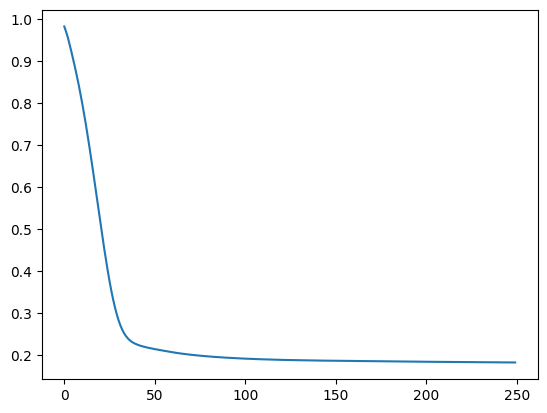

27.741037
23.53698
0.4088145896656535
3.942787243568921


In [1]:
import copy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import tqdm
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
# Load the dataset from the uploaded file
df = pd.read_csv("shuffled_sec_part_data.csv")

df['gtv_average'] = np.degrees(df['gtv_average'])
df['pta_average'] = np.degrees(df['pta_average'])
df['gza_average'] = np.degrees(df['gza_average'])
df['gtv_min_average'] = np.degrees(df['gtv_min_average'])
df['gtv_max_average'] = np.degrees(df['gtv_max_average'])
df['hga_average'] = np.degrees( df['hga_average'])

# Further split the training and validation data
train_data = df[:1895]

val_data = df[1895: 2294]

test_data = df[2294 : ]


# Extract predictors and target
TargetVariable = ['gtv_average']
Predictors = ['pta_average', 'gza_average', 'hga_average']

X_train = (train_data[Predictors].values)
y_train = (train_data[TargetVariable].values)
    
X_test = (val_data[Predictors].values)
y_test = (val_data[TargetVariable].values)

x_t = (test_data[Predictors].values)
y_t = (test_data[TargetVariable].values)



from sklearn.preprocessing import StandardScaler


### Sandardization of data ###
from sklearn.preprocessing import StandardScaler
PredictorScaler=StandardScaler()
TargetVarScaler=StandardScaler()
 
# Storing the fit object for later reference
PredictorScalerFit=PredictorScaler.fit(X_train)
TargetVarScalerFit=TargetVarScaler.fit(y_train)
 
# Generating the standardized values of X and y
X_train=PredictorScalerFit.transform(X_train)
y_train=TargetVarScalerFit.transform(y_train)
X_test=PredictorScalerFit.transform(X_test)
y_test=TargetVarScalerFit.transform(y_test)

x_t=PredictorScalerFit.transform(x_t)
y_t=TargetVarScalerFit.transform(y_t)
x_t = torch.tensor(x_t, dtype=torch.float32)
y_t = torch.tensor(y_t, dtype=torch.float32)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)




# Read data
#data = fetch_california_housing()
#X, y = data.data, data.target

# train-test split for model evaluation
#X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=True)

# Convert to 2D PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)
x_t = torch.tensor(x_t, dtype=torch.float32)
y_t = torch.tensor(y_t, dtype=torch.float32)

# Define the model
model = nn.Sequential(
    nn.Linear(3, 12),
    nn.ReLU(),
    nn.Linear(12, 24),
    nn.ReLU(),
    nn.Linear(24, 12),
    nn.ReLU(),
    nn.Linear(12, 1)
)

# loss function and optimizer
loss_fn = nn.MSELoss()  # mean square error
optimizer = optim.Adam(model.parameters(), lr=0.0001)

n_epochs = 250   # number of epochs to run
batch_size = 100  # size of each batch
batch_start = torch.arange(0, len(X_train), batch_size)

# Hold the best model
best_mse = np.inf   # init to infinity
best_weights = None
history = []

for epoch in range(n_epochs):
    model.train()
    with tqdm.tqdm(batch_start, unit="batch", mininterval=0, disable=True) as bar:
        bar.set_description(f"Epoch {epoch}")
        for start in bar:
            # take a batch
            X_batch = X_train[start:start+batch_size]
            y_batch = y_train[start:start+batch_size]
            # forward pass
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            # backward pass
            optimizer.zero_grad()
            loss.backward()
            # update weights
            optimizer.step()
            # print progress
            bar.set_postfix(mse=float(loss))
    # evaluate accuracy at end of each epoch
    model.eval()
    y_pred = model(X_test)
    mse = loss_fn(y_pred, y_test)
    mse = float(mse)
    history.append(mse)
    if mse < best_mse:
        best_mse = mse
        best_weights = copy.deepcopy(model.state_dict())

# restore model and return best accuracy
model.load_state_dict(best_weights)
print("MSE: " , best_mse)
print("RMSE: " , np.sqrt(best_mse))
plt.plot(history)
plt.show()

a = TargetVarScalerFit.inverse_transform(model(X_test).detach().numpy())
from sklearn.metrics import mean_squared_error
rms = mean_squared_error(y_test.numpy(), a, squared=False)
print(rms)
a = TargetVarScalerFit.inverse_transform(model(x_t).detach().numpy())
rms = mean_squared_error(y_t.numpy(), a, squared=False)
print(rms)
a_flat = a[:, 0]
hbw = abs(test_data['gtv_min_average'] - test_data['gtv_max_average'])/2

acc= abs( test_data['gtv_average'] -  a[:, 0] ) / hbw
print(( acc < 1).sum() / len(acc)  )

print( acc .sum() / len(acc)  )
pointing_model =model
scaled_predictions = TargetVarScalerFit.inverse_transform(model(X_train).detach().numpy())




In [4]:
# Assuming 'participant_id' column in test_data to identify participants
# If you don't have it, make sure to include one for each participant.
participant_ids = test_data['participant'].values  # Replace with correct column name

# Recalculate predictions for the test set
scaled_predictions_test = TargetVarScalerFit.inverse_transform(model(x_t).detach().numpy())

hbw = abs(test_data['gtv_min_average'] - test_data['gtv_max_average'])/2
# Compute the absolute percentage error per participant
errors = abs(test_data['gtv_average'] - scaled_predictions_test[:, 0]) / hbw


# Create a DataFrame to organize the errors by participant
results_df = pd.DataFrame({
    'participant_id': participant_ids,
    'target': test_data['gtv_average'].values,
    'predictions': scaled_predictions_test[:, 0],
    'errors': errors
})


threshold = 1  

# Calculate accuracy per participant
participant_mrde = results_df.groupby('participant_id').apply(lambda df: (df['errors']).mean())

print('Standard error: ', np.std(participant_mrde)/ (len(participant_mrde)**0.5))

Standard error:  0.9523061340627667


1895
399
(1895, 3)
(1895, 1)
(399, 3)
(399, 1)


c:\users\kiran\appdata\local\programs\python\python37\lib\site-packages\ipykernel_launcher.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
c:\users\kiran\appdata\local\programs\python\python37\lib\site-packages\ipykernel_launcher.py:90: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).


MSE:  0.17823976278305054
RMSE:  0.422184512722874


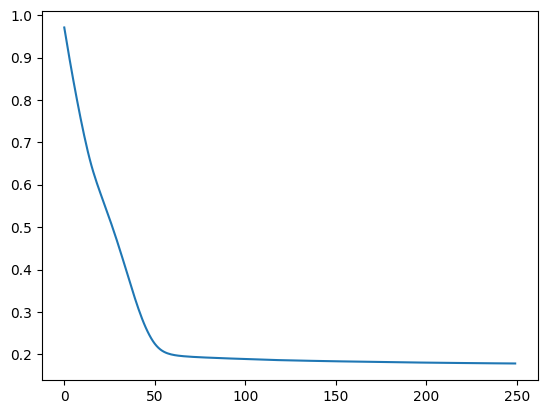

27.795252
23.303972
0.6565349544072948
1.1697628469515429


In [5]:
import copy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import tqdm
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
# Load the dataset from the uploaded file
df = pd.read_csv("shuffled_sec_part_data.csv")

df['gtl_average'] = np.degrees(df['gtl_average'])
df['pta_average'] = np.degrees(df['pta_average'])
df['gza_average'] = np.degrees(df['gza_average'])
df['gtl_min_average'] = np.degrees(df['gtl_min_average'])
df['gtl_max_average'] = np.degrees(df['gtl_max_average'])
df['hga_average'] = np.degrees( df['hga_average'])


# Further split the training and validation data
train_data = df[:1895]

val_data = df[1895: 2294]

test_data = df[2294 : ]

# Extract predictors and target
TargetVariable = ['gtl_average']
Predictors = ['pta_average', 'gza_average', 'hga_average']

X_train = (train_data[Predictors].values)
y_train = (train_data[TargetVariable].values)
    
X_test = (val_data[Predictors].values)
y_test = (val_data[TargetVariable].values)

x_t = (test_data[Predictors].values)
y_t = (test_data[TargetVariable].values)



from sklearn.preprocessing import StandardScaler


### Sandardization of data ###
from sklearn.preprocessing import StandardScaler
PredictorScaler=StandardScaler()
TargetVarScaler=StandardScaler()
 
# Storing the fit object for later reference
PredictorScalerFit=PredictorScaler.fit(X_train)
TargetVarScalerFit=TargetVarScaler.fit(y_train)
 
# Generating the standardized values of X and y
X_train=PredictorScalerFit.transform(X_train)
y_train=TargetVarScalerFit.transform(y_train)
X_test=PredictorScalerFit.transform(X_test)
y_test=TargetVarScalerFit.transform(y_test)

x_t=PredictorScalerFit.transform(x_t)
y_t=TargetVarScalerFit.transform(y_t)
x_t = torch.tensor(x_t, dtype=torch.float32)
y_t = torch.tensor(y_t, dtype=torch.float32)

print(len(X_train))
print(len(X_test))
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)




# Read data
#data = fetch_california_housing()
#X, y = data.data, data.target

# train-test split for model evaluation
#X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=True)

# Convert to 2D PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)
x_t = torch.tensor(x_t, dtype=torch.float32)
y_t = torch.tensor(y_t, dtype=torch.float32)

# Define the model
model = nn.Sequential(
    nn.Linear(3, 12),
    nn.ReLU(),
    nn.Linear(12, 24),
    nn.ReLU(),
    nn.Linear(24, 12),
    nn.ReLU(),
    nn.Linear(12, 1)
)

# loss function and optimizer
loss_fn = nn.MSELoss()  # mean square error
optimizer = optim.Adam(model.parameters(), lr=0.0001)

n_epochs = 250   # number of epochs to run
batch_size = 100  # size of each batch
batch_start = torch.arange(0, len(X_train), batch_size)

# Hold the best model
best_mse = np.inf   # init to infinity
best_weights = None
history = []

for epoch in range(n_epochs):
    model.train()
    with tqdm.tqdm(batch_start, unit="batch", mininterval=0, disable=True) as bar:
        bar.set_description(f"Epoch {epoch}")
        for start in bar:
            # take a batch
            X_batch = X_train[start:start+batch_size]
            y_batch = y_train[start:start+batch_size]
            # forward pass
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            # backward pass
            optimizer.zero_grad()
            loss.backward()
            # update weights
            optimizer.step()
            # print progress
            bar.set_postfix(mse=float(loss))
    # evaluate accuracy at end of each epoch
    model.eval()
    y_pred = model(X_test)
    mse = loss_fn(y_pred, y_test)
    mse = float(mse)
    history.append(mse)
    if mse < best_mse:
        best_mse = mse
        best_weights = copy.deepcopy(model.state_dict())

# restore model and return best accuracy
model.load_state_dict(best_weights)
print("MSE: " , best_mse)
print("RMSE: " , np.sqrt(best_mse))
plt.plot(history)
plt.show()

a = TargetVarScalerFit.inverse_transform(model(X_test).detach().numpy())
from sklearn.metrics import mean_squared_error
rms = mean_squared_error(y_test.numpy(), a, squared=False)
print(rms)
a = TargetVarScalerFit.inverse_transform(model(x_t).detach().numpy())
rms = mean_squared_error(y_t.numpy(), a, squared=False)
print(rms)
a_flat = a[:, 0]
hbw = abs(test_data['gtl_min_average'] - test_data['gtl_max_average'])/2

acc= abs( test_data['gtl_average'] -  a[:, 0] ) / hbw
print(( acc < 1).sum() / len(acc)  )

print( acc .sum() / len(acc)  )
pointing_model =model
scaled_predictions = TargetVarScalerFit.inverse_transform(model(X_train).detach().numpy())





In [6]:
# Assuming 'participant_id' column in test_data to identify participants
# If you don't have it, make sure to include one for each participant.
participant_ids = test_data['participant'].values  # Replace with correct column name

# Recalculate predictions for the test set
scaled_predictions_test = TargetVarScalerFit.inverse_transform(model(x_t).detach().numpy())

hbw = abs(test_data['gtl_min_average'] - test_data['gtl_max_average'])/2
# Compute the absolute percentage error per participant
errors = abs(test_data['gtl_average'] - scaled_predictions_test[:, 0]) / hbw


# Create a DataFrame to organize the errors by participant
results_df = pd.DataFrame({
    'participant_id': participant_ids,
    'target': test_data['gtl_average'].values,
    'predictions': scaled_predictions_test[:, 0],
    'errors': errors
})


threshold = 1  

# Calculate accuracy per participant
participant_mrde = results_df.groupby('participant_id').apply(lambda df: (df['errors']).mean())

print('Standard error: ', np.std(participant_mrde)/ (len(participant_mrde)**0.5))

Standard error:  0.1591526692338303
